In [1]:
# Import các module từ src
import sys
sys.path.append('../') # Để gọi được thư mục src

from src.data.loader import load_config, load_raw_data, validate_data

# 1. Load cấu hình
config = load_config("../configs/params.yaml")

# 2. Load dữ liệu (Sửa lại path trong config nếu chạy từ notebook)
config['data']['raw_path'] = "../data/raw/ai4i2020.csv" 
df = load_raw_data(config)

# 3. Kiểm tra
if validate_data(df, config):
    display(df.head())

✅ Đã tải dữ liệu thành công từ: ../data/raw/ai4i2020.csv
✅ Kiểm tra định dạng dữ liệu: Hợp lệ.


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

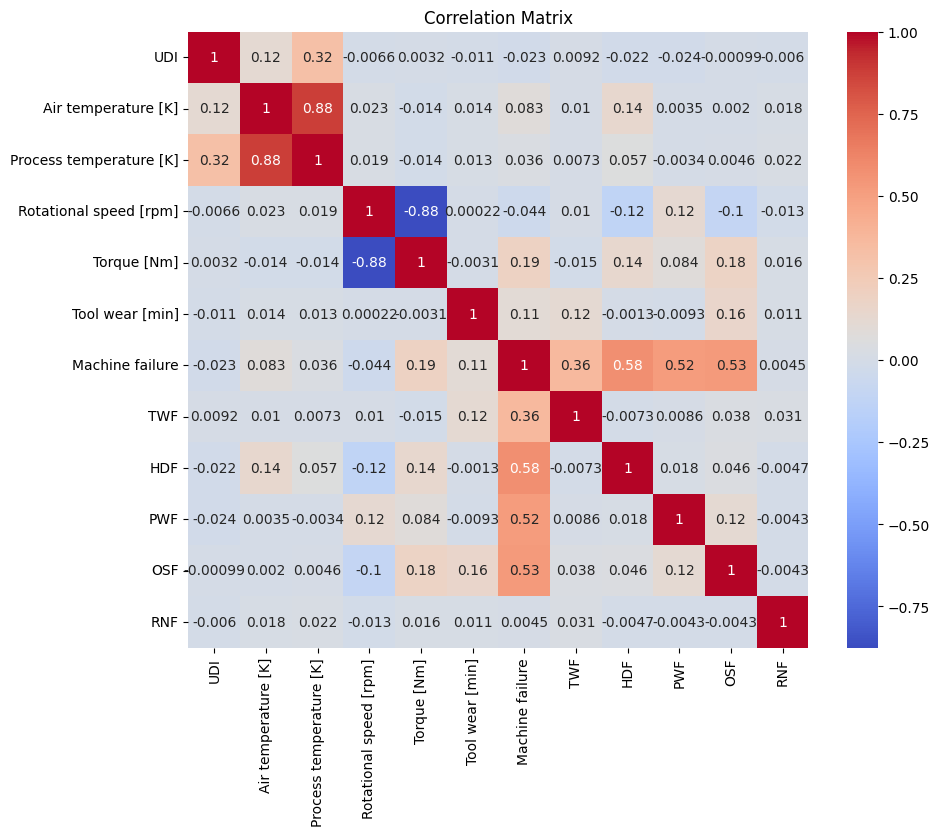

✅ Đã lưu kết quả EDA vào outputs/figures và outputs/tables


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lưu ma trận tương quan vào outputs/figures
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
# Lưu ảnh
plt.savefig("../outputs/figures/eda_correlation_matrix.png")
plt.show()

# 2. Lưu thống kê mô tả vào outputs/tables
summary_stats = df.describe()
summary_stats.to_csv("../outputs/tables/eda_summary_statistics.csv")

print("✅ Đã lưu kết quả EDA vào outputs/figures và outputs/tables")